In [1]:
from typing import Self

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [3]:
train = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train, val = random_split(train, [50000, 10000])

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.15MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 352kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 20.6MB/s]


In [4]:
train_loader = DataLoader(train, batch_size=64, shuffle=True)
val_loader = DataLoader(val, batch_size=64, shuffle=True)
test_loader = DataLoader(test, batch_size=64, shuffle=True)

In [5]:
class Perceptron(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, activation=nn.ReLU()):
        super(Perceptron, self).__init__()
        layers = []
        in_dim = input_size

        for h_dim in hidden_sizes:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(activation)
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, num_classes))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.layers(x)

In [11]:
def train(model, optimizer, criterion=nn.CrossEntropyLoss(), epochs=10):
    optimizer = optimizer(model.parameters())
    history = {
        'train_loss': [],
        'val_loss': [],
        'accuracy': []
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        total, correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        accuracy = 100 * correct / total

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['accuracy'].append(accuracy)

    return history

In [8]:
model1 = Perceptron(28*28, [128], 10, activation=nn.ReLU())
model2 = Perceptron(28*28, [256, 128], 10, activation=nn.LeakyReLU())
model3 = Perceptron(28*28, [512, 256, 128], 10, activation=nn.Tanh())

In [12]:
model1_res = train(model1, optimizer=optim.SGD)
model2_res = train(model2, optimizer=optim.Adam)
model3_res = train(model3, optimizer=optim.RMSprop)

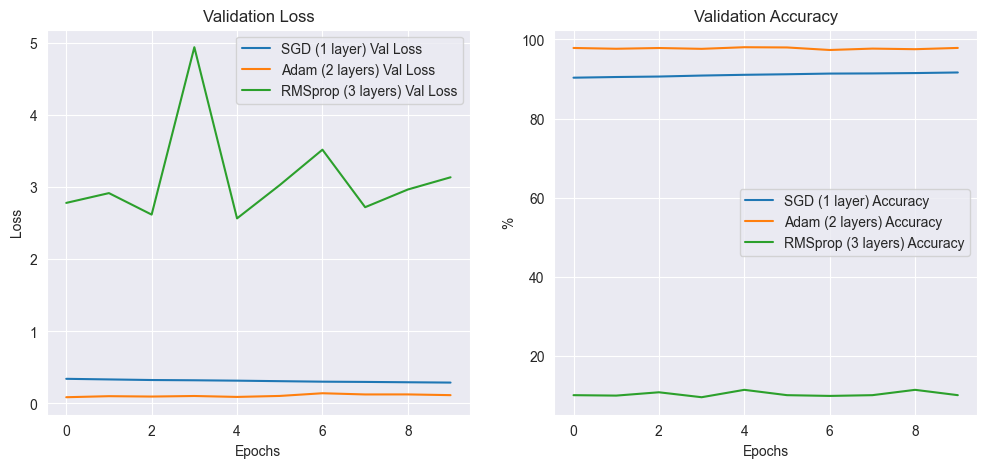

In [13]:
import matplotlib.pyplot as plt

def plot_results(results_dict):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for name, res in results_dict.items():
        plt.plot(res['val_loss'], label=f'{name} Val Loss')
    plt.title('Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    for name, res in results_dict.items():
        plt.plot(res['accuracy'], label=f'{name} Accuracy')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('%')
    plt.legend()

    plt.show()

all_results = {
    "SGD (1 layer)": model1_res,
    "Adam (2 layers)": model2_res,
    "RMSprop (3 layers)": model3_res
}
plot_results(all_results)

In [14]:
def evaluate_test(model, name):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'[{name}] Accuracy на тесте: {100 * correct / total:.2f}%')

evaluate_test(model1, "SGD (1 layer)")
evaluate_test(model2, "Adam (2 layers)")
evaluate_test(model3, "RMSprop (3 layers)")

[SGD (1 layer)] Accuracy на тесте: 92.17%
[Adam (2 layers)] Accuracy на тесте: 97.91%
[RMSprop (3 layers)] Accuracy на тесте: 9.80%
